Comparing with vanilla NPE

In [2]:
import torch
from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.analysis import pairplot
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader
import lampe
import corner
import zuko

/home/oestequeda/Desktop/Workstation/PFN_pewpew_analytics/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ==========================================
# 1. CONSTANTS & SETUP
# ==========================================
SENSOR_FS = 0.24
#SENSOR_FS = 60.0
RECORD_DURATION = 100.0
num_samples = int(SENSOR_FS * RECORD_DURATION)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Simulator

In [6]:
# ==========================================
# 2. SIMULATOR & DATASET
# ==========================================
def thermal_simulator_abc(theta, fs=0.24, duration=100.0):
    """5-Parameter Physics Model"""
    k, T_env, t_0, T_initial, sigma = theta[0], theta[1], theta[2], theta[3], theta[4]
    
    num_steps = int(fs * duration)
    # FIX: Tell 't' to live on the same device as 'theta'
    t = torch.linspace(0.0, duration, steps=num_steps, device=theta.device)
    
    clean_curve = T_env + (T_initial - T_env) * torch.exp(-k * (t - t_0))
    noise = torch.randn_like(clean_curve) * sigma
    return clean_curve + noise

class DynamicThermalDatasetABC(IterableDataset):
    def __init__(self, batch_size=256, fs=0.26, duration=100.0, sigma_bounds=(0.0, 5.0)):
        super().__init__()
        self.batch_size = batch_size
        self.fs = fs
        self.duration = duration
        
        self.lower_bounds = torch.tensor([0.03, 300.0, -5.0, 300.0, sigma_bounds[0]])
        self.upper_bounds = torch.tensor([0.05,   310.0,  5.0, 350.0, sigma_bounds[1]])
        
    def __iter__(self):
        while True:
            u = torch.rand((self.batch_size, 5))
            theta_batch = self.lower_bounds + u * (self.upper_bounds - self.lower_bounds)
            
            x_list = [
                thermal_simulator_abc(t, self.fs, self.duration) 
                for t in theta_batch
            ]
            x_batch = torch.stack(x_list)
            yield theta_batch, x_batch

In [7]:
# ==========================================
# 3. NORMALIZER UTILITIES
# ==========================================
class ThetaNormalizer:
    def __init__(self, lower_bounds, upper_bounds, device):
        self.low = lower_bounds.to(device)
        self.high = upper_bounds.to(device)

    def normalize(self, theta):
        return 2.0 * (theta - self.low) / (self.high - self.low) - 1.0

    def unnormalize(self, theta_norm):
        return self.low + (theta_norm + 1.0) / 2.0 * (self.high - self.low)

class XNormalizer:
    def __init__(self, dataset, device, num_samples=5000):
        print("Calculating dataset statistics for x normalization...")
        loader = DataLoader(dataset, batch_size=num_samples)
        _, x_dummy = next(iter(loader))
        self.mean = x_dummy.mean().to(device)
        self.std = x_dummy.std().to(device)

    def normalize(self, x):
        return (x - self.mean) / self.std

Initializing

In [8]:
# ==========================================
# 4. INITIALIZATION
# ==========================================
dataset = DynamicThermalDatasetABC(
    batch_size=256, fs=SENSOR_FS, duration=RECORD_DURATION, sigma_bounds=(0.1, 5.0)
)
dataloader = DataLoader(dataset, batch_size=None)
data_iter = iter(dataloader)

# Initialize normalizers
theta_norm_layer = ThetaNormalizer(dataset.lower_bounds, dataset.upper_bounds, device)
x_norm_layer = XNormalizer(dataset, device)

# Initialize Custom Architecture (Neural Spline Flow, 3 layers of 128)
# 2. Shrink the Architecture
MAX_NETWORK_INPUTS = 24
estimator = lampe.inference.NPE(
    theta_dim=5, 
    x_dim=MAX_NETWORK_INPUTS, 
    build=zuko.flows.NSF,            
    transforms=3,                     # Fewer transforms needed for lower-dim data
    hidden_features=[64, 64]          # Much smaller hidden layers required
).to(device)

epochs = 50
steps_per_epoch = 100

optimizer = torch.optim.Adam(estimator.parameters(), lr=1e-3)
# Cosine Annealing Scheduler for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * steps_per_epoch, eta_min=1e-5)

Calculating dataset statistics for x normalization...


Training loop

In [42]:
# ==========================================
# 5. PHASE 1: RAPID EXPLORATION
# ==========================================
print(f"\n--- PHASE 1: Rapid Exploration ---")
# High LR, smaller batch size for fast stochastic updates
phase1_epochs = 300
steps_per_epoch = 100
dataset_p1 = DynamicThermalDatasetABC(batch_size=1024, fs=SENSOR_FS, duration=RECORD_DURATION)
data_iter_p1 = iter(DataLoader(dataset_p1, batch_size=None))

optimizer_p1 = torch.optim.Adam(estimator.parameters(), lr=1e-3)

estimator.train()
for epoch in range(phase1_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        theta_train, x_train = next(data_iter_p1)
        theta_train, x_train = theta_train.to(device), x_train.to(device)
        
        theta_norm = theta_norm_layer.normalize(theta_train)
        x_norm = x_norm_layer.normalize(x_train)
        
        optimizer_p1.zero_grad()
        loss = -estimator(theta_norm, x_norm).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(estimator.parameters(), 1.0)
        optimizer_p1.step()
        epoch_loss += loss.item()
        
    print(f"P1 Epoch {epoch+1:03d} | Loss: {epoch_loss / steps_per_epoch:.4f}")

# ==========================================
# 6. PHASE 2: LOCAL MINIMIZING
# ==========================================
print(f"\n--- PHASE 2: Local Minimization ---")
# Very low LR, much larger batch size to reduce gradient noise
phase2_epochs = 100
dataset_p2 = DynamicThermalDatasetABC(batch_size=4096, fs=SENSOR_FS, duration=RECORD_DURATION)
data_iter_p2 = iter(DataLoader(dataset_p2, batch_size=None))

# Re-initialize optimizer with a much smaller learning rate
optimizer_p2 = torch.optim.Adam(estimator.parameters(), lr=1e-5)

for epoch in range(phase2_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        theta_train, x_train = next(data_iter_p2)
        theta_train, x_train = theta_train.to(device), x_train.to(device)
        
        theta_norm = theta_norm_layer.normalize(theta_train)
        x_norm = x_norm_layer.normalize(x_train)
        
        optimizer_p2.zero_grad()
        loss = -estimator(theta_norm, x_norm).mean()
        loss.backward()
        # Tighter gradient clipping for stability in the fine-tuning phase
        torch.nn.utils.clip_grad_norm_(estimator.parameters(), 0.5) 
        optimizer_p2.step()
        epoch_loss += loss.item()
        
    print(f"P2 Epoch {epoch+1:03d} | Loss: {epoch_loss / steps_per_epoch:.4f}")


--- PHASE 1: Rapid Exploration ---
P1 Epoch 001 | Loss: 1.6279
P1 Epoch 002 | Loss: -0.2810
P1 Epoch 003 | Loss: -0.7138
P1 Epoch 004 | Loss: -1.0116
P1 Epoch 005 | Loss: -1.2229
P1 Epoch 006 | Loss: -1.3655
P1 Epoch 007 | Loss: -1.4850
P1 Epoch 008 | Loss: -1.5599
P1 Epoch 009 | Loss: -1.6375
P1 Epoch 010 | Loss: -1.6887
P1 Epoch 011 | Loss: -1.7459
P1 Epoch 012 | Loss: -1.7854
P1 Epoch 013 | Loss: -1.8278
P1 Epoch 014 | Loss: -1.8687
P1 Epoch 015 | Loss: -1.8941
P1 Epoch 016 | Loss: -1.9172
P1 Epoch 017 | Loss: -1.9220
P1 Epoch 018 | Loss: -1.9216
P1 Epoch 019 | Loss: -2.0022
P1 Epoch 020 | Loss: -2.0312
P1 Epoch 021 | Loss: -1.9908
P1 Epoch 022 | Loss: -2.0360
P1 Epoch 023 | Loss: -2.0437
P1 Epoch 024 | Loss: -2.0565
P1 Epoch 025 | Loss: -2.0902
P1 Epoch 026 | Loss: -2.0988
P1 Epoch 027 | Loss: -2.0646
P1 Epoch 028 | Loss: -2.1560
P1 Epoch 029 | Loss: -2.0982
P1 Epoch 030 | Loss: -2.1436
P1 Epoch 031 | Loss: -2.1710
P1 Epoch 032 | Loss: -2.1153
P1 Epoch 033 | Loss: -2.1671
P1 Epoch

Testing

Generating posterior predictive corner plot...


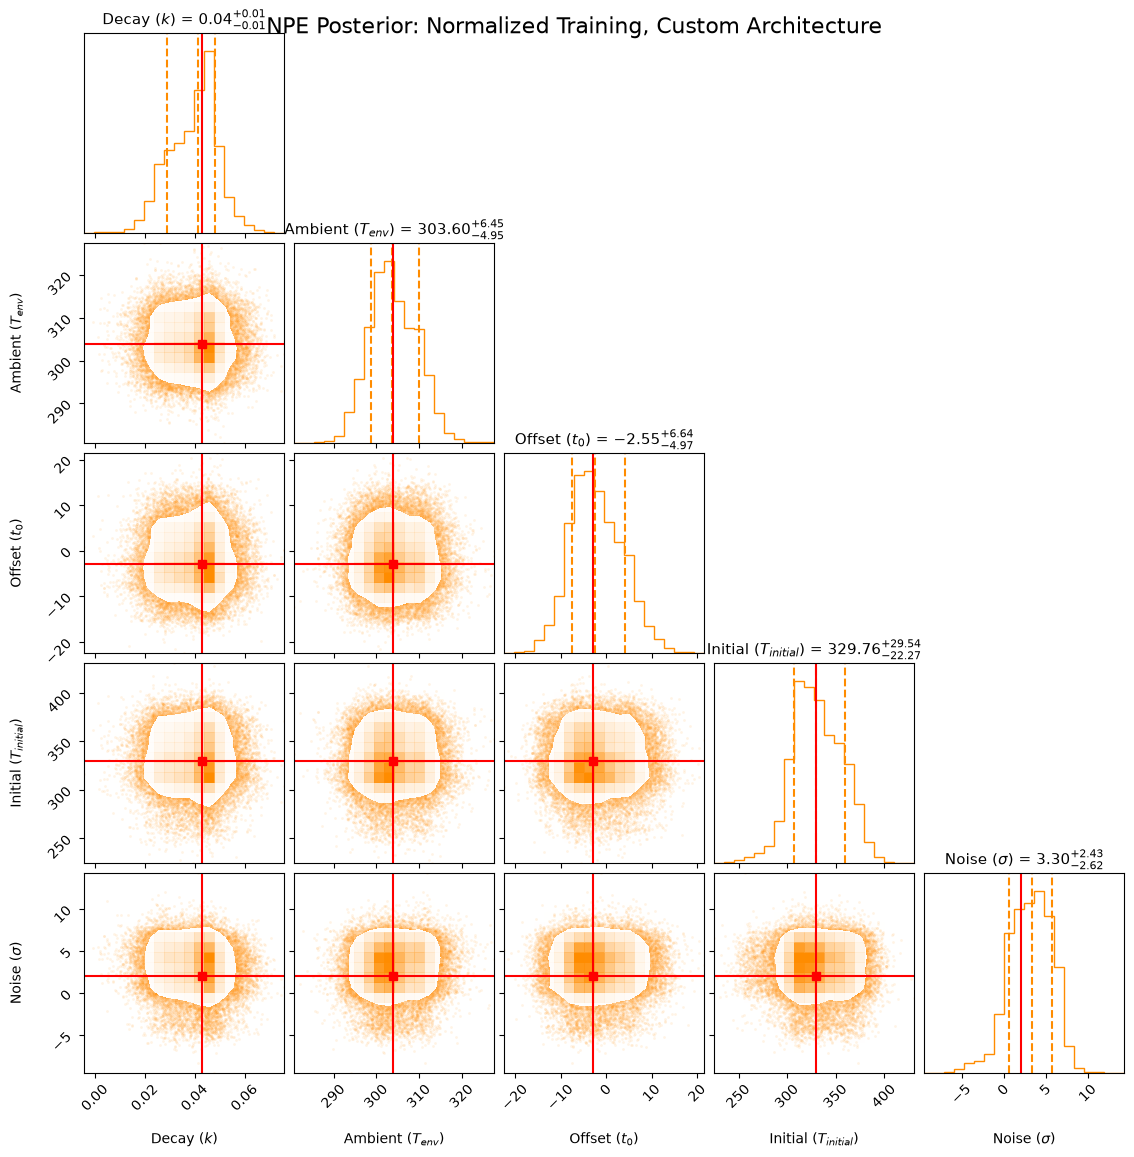

In [9]:
# ==========================================
# 6. INFERENCE & PLOTTING
# ==========================================
print("Generating posterior predictive corner plot...")
estimator.eval()

with torch.no_grad():
    # True values
    true_theta_tensor = torch.tensor([0.043, 304.0, -3.0, 330.0, 2.0]).to(device)
    
    # Generate the synthetic observation
    x_real = thermal_simulator_abc(true_theta_tensor, SENSOR_FS, RECORD_DURATION).to(device)
    
    # NORMALIZE x before passing to the estimator
    x_real_norm = x_norm_layer.normalize(x_real)
    
    # Sample the posterior (in normalized space)
    samples_norm = estimator.flow(x_real_norm).sample((50000,))
    
    # UN-NORMALIZE samples back to physical space for interpretation
    samples_physical = theta_norm_layer.unnormalize(samples_norm)
    samples_np = samples_physical.cpu().numpy()

# Plot the 5x5 grid
fig = corner.corner(
    samples_np,
    labels=[
        r"Decay ($k$)", r"Ambient ($T_{env}$)", r"Offset ($t_0$)", 
        r"Initial ($T_{initial}$)", r"Noise ($\sigma$)"
    ],
    show_titles=True,
    title_kwargs={"fontsize": 11},
    quantiles=[0.16, 0.5, 0.84],
    color="darkorange",
    truths=[0.043, 304.0, -3.0, 330.0, 2.0],
    truth_color="red",
    plot_contours=False,
    plot_density=True,
    figsize=(12, 12)
)

plt.suptitle("NPE Posterior: Normalized Training, Custom Architecture", fontsize=16)
plt.show()

Now trying with the real data

In [44]:
# ==========================================
# 1. Real Data Loading
# ==========================================
import pandas as pd
import numpy as np
import os
import tempfile

# Load your collected sensor data here. 
file_path = './data/sequence_2/sequence_2_timeseries.csv'
min_time = 20.0  # Cutoff time from main.ipynb

try:
    df_data = pd.read_csv(file_path)
    
    # --- Minimum Time Filter (from main.ipynb) ---
    original_len = len(df_data)
    df_data = df_data[df_data['relative_time_sec'] >= min_time].copy()
    print(f"Time trim: Removed {original_len - len(df_data)} frames prior to t={min_time:.2f}s")
    
    # Extract arrays
    time_steps = df_data['relative_time_sec'].values
    sensor_data = df_data['max_temperature_kelvin'].values
    
    # CRITICAL: Shift the time series so it starts at t=0
    # This ensures newtons_cooling() correctly uses T0 at the first time step
    time_steps = time_steps - time_steps[0]
    
    print(f"Successfully loaded {len(time_steps)} data points.")
except FileNotFoundError:
    print(f"Warning: '{file_path}' not found. Generating a dummy dataset so the script can run.")

# Set the initial temperature to the very first sensor reading (after the trim)
T0 = sensor_data[0]

# The updated mathematical equation with a t_0 shift
def newtons_cooling(k, T_env, t, t_0, T_initial):
    return T_env + (T_initial - T_env) * np.exp(-k * (t - t_0))

# Package the real observations for pyabc
observation = {"temperature_curve": sensor_data}

Time trim: Removed 3 frames prior to t=20.00s
Successfully loaded 24 data points.


In [45]:
# Assuming you just finished training, extract these:
saved_x_mean = x_norm_layer.mean
saved_x_std = x_norm_layer.std

# You also need the exact bounds used during training
saved_lower_bounds = theta_norm_layer.low
saved_upper_bounds = theta_norm_layer.high

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Assumes these functions are defined elsewhere in your script:
# from your_module import newtons_cooling, plot_kde_1d

def plot_comparative_sbi_analysis(history_A, history_B, 
                                  t_real_A, temp_real_A, 
                                  t_real_B, temp_real_B, 
                                  ground_truth_A=None, ground_truth_B=None,
                                  num_samples=1000, 
                                  save_dir="."):
    """
    Generates a composite figure comparing two thermal decay profiles.
    Top row: Split posterior predictive checks.
    Bottom row: Shared parameter marginal distributions.
    """
    
    # 1. Publication-ready typography and styling
    plt.rcParams.update({
        'font.size': 14,
        'font.family': 'serif', 
        'axes.labelsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })
    
    # 2. Extract the final distributions from both ABC histories
    df_A, w_A = history_A.get_distribution(m=0, t=history_A.max_t)
    df_B, w_B = history_B.get_distribution(m=0, t=history_B.max_t)
    
    # 3. Initialize the GridSpec layout
    fig = plt.figure(figsize=(16, 9))
    gs = GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.3)
    
    # ==========================================
    # TOP ROW: Split Posterior Predictives
    # ==========================================
    
    def plot_predictive(ax, df, w, t_real, temp_real, title, color_fit, color_data):
        # Sample parameter sets
        sample_indices = np.random.choice(len(df), size=num_samples, p=w)
        simulated_trajectories = np.zeros((num_samples, len(t_real)))
        
        for idx, row_idx in enumerate(sample_indices):
            row = df.iloc[row_idx]
            k_sample = row['k']
            T_env_sample = row['T_env']
            T0_sample = row['T_initial']
            t_0_sample = row.get('t_0', 0.0) 
            
            simulated_trajectories[idx, :] = newtons_cooling(k_sample, T_env_sample, t_real, t_0_sample, T0_sample)
            
        # Calculate percentiles
        median_pred = np.percentile(simulated_trajectories, 50, axis=0)
        lower_95 = np.percentile(simulated_trajectories, 2.5, axis=0)
        upper_95 = np.percentile(simulated_trajectories, 97.5, axis=0)
        lower_68 = np.percentile(simulated_trajectories, 16, axis=0)
        upper_68 = np.percentile(simulated_trajectories, 84, axis=0)
        
        # Plot Bands and Median
        ax.fill_between(t_real, lower_95, upper_95, color=color_fit, alpha=0.15, edgecolor='none')
        ax.fill_between(t_real, lower_68, upper_68, color=color_fit, alpha=0.3, edgecolor='none')
        ax.plot(t_real, median_pred, color=color_fit, linewidth=2, label='Median Prediction')
        
        # Overlay Real Data
        ax.scatter(t_real, temp_real, color=color_data, alpha=0.6, s=30, edgecolors='none', label='Sensor Data', zorder=5)
        
        # Aesthetics
        ax.set_title(title, fontsize=16, pad=10)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Temperature (K)")
        ax.legend(loc='upper right', frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4, color='gray')

    # Assign left columns (0, 1) to Profile A and right columns (2, 3) to Profile B
    ax_pred_A = fig.add_subplot(gs[0, 0:2])
    plot_predictive(ax_pred_A, df_A, w_A, t_real_A, temp_real_A, 
                    "Posterior Predictive: Profile A", '#93003a', '#00429d')
    
    ax_pred_B = fig.add_subplot(gs[0, 2:4])
    plot_predictive(ax_pred_B, df_B, w_B, t_real_B, temp_real_B, 
                    "Posterior Predictive: Profile B", '#d45087', '#00798c')
    
    # ==========================================
    # BOTTOM ROW: Shared Marginal Posteriors
    # ==========================================
    params = ["k", "T_env", "T_initial", "sigma"] 
    
    for i, param in enumerate(params):
        ax_marg = fig.add_subplot(gs[1, i])
        
        # Plot KDE for Profile A
        plot_kde_1d(df_A, w_A, x=param, ax=ax_marg)
        lines = ax_marg.get_lines()
        if len(lines) > 0:
            line_A = lines[-1]
            line_A.set_color('#00429d')
            line_A.set_linewidth(2)
            line_A.set_label('Profile A')
            
        # Plot KDE for Profile B
        plot_kde_1d(df_B, w_B, x=param, ax=ax_marg)
        lines = ax_marg.get_lines()
        if len(lines) > 1:
            line_B = lines[-1]
            line_B.set_color('#00798c')
            line_B.set_linewidth(2)
            line_B.set_label('Profile B')
            
        # Optional: Add ground truth vertical lines if dictionaries are provided
        if ground_truth_A and param in ground_truth_A:
            ax_marg.axvline(ground_truth_A[param], color='#00429d', linestyle=':', linewidth=2, alpha=0.7)
        if ground_truth_B and param in ground_truth_B:
            ax_marg.axvline(ground_truth_B[param], color='#00798c', linestyle=':', linewidth=2, alpha=0.7)
            
        # Aesthetics for marginals
        ax_marg.set_title(f"Marginal: {param}", fontsize=14)
        ax_marg.spines['top'].set_visible(False)
        ax_marg.spines['right'].set_visible(False)
        ax_marg.grid(True, linestyle=':', alpha=0.4, color='gray')
        
        if i == 0:
            ax_marg.set_ylabel("Density")
            ax_marg.legend(loc='best', frameon=False, fontsize=10)
        else:
            ax_marg.set_ylabel("") # Remove redundant y-labels
            
    # ==========================================
    # Finalization and Export
    # ==========================================
    plt.tight_layout()
    
    # Ensure export directory exists
    os.makedirs(save_dir, exist_ok=True)
    
    # Save as PDF and SVG for high-quality typesetting integration
    pdf_path = os.path.join(save_dir, "comparative_sbi_analysis.pdf")
    svg_path = os.path.join(save_dir, "comparative_sbi_analysis.svg")
    
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    plt.savefig(svg_path, format='svg', bbox_inches='tight')
    
    print(f"Plots saved successfully to:\n- {pdf_path}\n- {svg_path}")
    plt.show()